# Capsule Endoscopy (KAUHC) — AVM vs Normal vs Ulcer
### ConvNeXt V2 + Swin Transformer + Cross-Attention Fusion, 10-Fold CV, Grad-CAM XAI, HuggingFace Deployment

**Dataset:** `/kaggle/input/datasets/nisarahmedrana/capsule-endoscopy-dataset-kauhc`
**Classes:** `AVM`, `Normal`, `Ulcer`
**Hardware:** Kaggle T4 GPU (mixed precision, gradient accumulation used to fit memory)

This notebook is organized so every cell can run top-to-bottom on Kaggle:
1. Setup & installs
2. Data discovery + dataframe + EDA
3. Dataset / Dataloaders
4. Model: ConvNeXt V2 + Swin + Bidirectional Cross-Attention Fusion
5. Training / evaluation utilities (AMP, metrics)
6. **Stratified 10-Fold Cross-Validation training**
7. Aggregated results: accuracy, precision/recall/F1, ROC-AUC, confusion matrix, training curves
8. **Grad-CAM XAI** for both ConvNeXt and Swin streams
9. Save best fold model + export full results table for the paper
10. **Deploy to Hugging Face Hub**

> ⚠️ Note on runtime: training two transformer backbones x 10 folds on a single T4 is heavy.
> Defaults below use `EPOCHS_PER_FOLD = 12`, AMP (fp16), batch size 16, and `convnextv2_tiny` /
> `swin_tiny` (not large/huge variants) to keep this feasible in a single Kaggle session
> (~9hr GPU quota). Increase epochs/model size only if you have more more GPU time.


## 1. Setup & Installs

In [9]:

!pip install -q timm==1.0.* grad-cam huggingface_hub scikit-learn seaborn --upgrade


In [10]:

import os, gc, json, time, random, copy, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from torchvision import transforms
from PIL import Image

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              roc_auc_score, roc_curve, auc, confusion_matrix,
                              classification_report)
from sklearn.preprocessing import label_binarize

import timm

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "| GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")


Device: cuda | GPU: Tesla T4


## 2. Data Discovery & EDA
Scans the dataset directory, builds a dataframe of `filepath, label`, and shows class balance.
Adjust `DATA_ROOT` / `CLASS_NAMES` only if your folder names differ from `AVM`, `Normal`, `Ulcer`.

In [11]:

DATA_ROOT = "/kaggle/input/datasets/nisarahmedrana/capsule-endoscopy-dataset-kauhc"
CLASS_NAMES = ["AVM", "Normal", "Ulcer"]   # edit if your folder casing differs
NUM_CLASSES = len(CLASS_NAMES)
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

# Walk the dataset root and find class folders case-insensitively
def discover_dataset(root, class_names):
    # map lowercase folder name -> actual class name
    target_map = {c.lower(): c for c in class_names}
    records = []
    for dirpath, dirnames, filenames in os.walk(root):
        folder_name = os.path.basename(dirpath).lower()
        if folder_name in target_map:
            cls = target_map[folder_name]
            for f in filenames:
                if f.lower().endswith(IMG_EXTS):
                    records.append({"filepath": os.path.join(dirpath, f), "label": cls})
    return pd.DataFrame(records)

df = discover_dataset(DATA_ROOT, CLASS_NAMES)
print(f"Total images found: {len(df)}")
print(df["label"].value_counts())

if len(df) == 0:
    print("No images auto-discovered. Listing top-level structure for manual inspection:")
    for root, dirs, files in os.walk(DATA_ROOT):
        depth = root[len(DATA_ROOT):].count(os.sep)
        if depth <= 2:
            print(root, "->", dirs[:10], "files:", len(files))


Total images found: 3301
label
Normal    2156
AVM        673
Ulcer      472
Name: count, dtype: int64


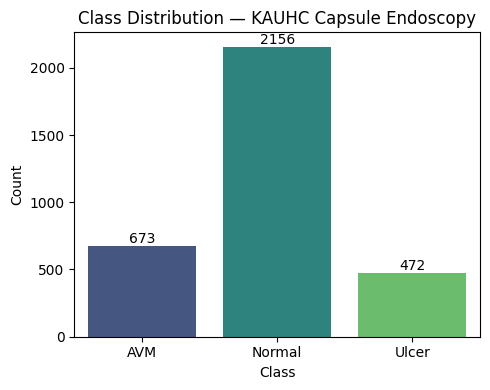

In [12]:

# Class distribution plot
fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(x="label", data=df, order=CLASS_NAMES, palette="viridis", ax=ax)
ax.set_title("Class Distribution — KAUHC Capsule Endoscopy")
ax.set_xlabel("Class"); ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=200)
plt.show()


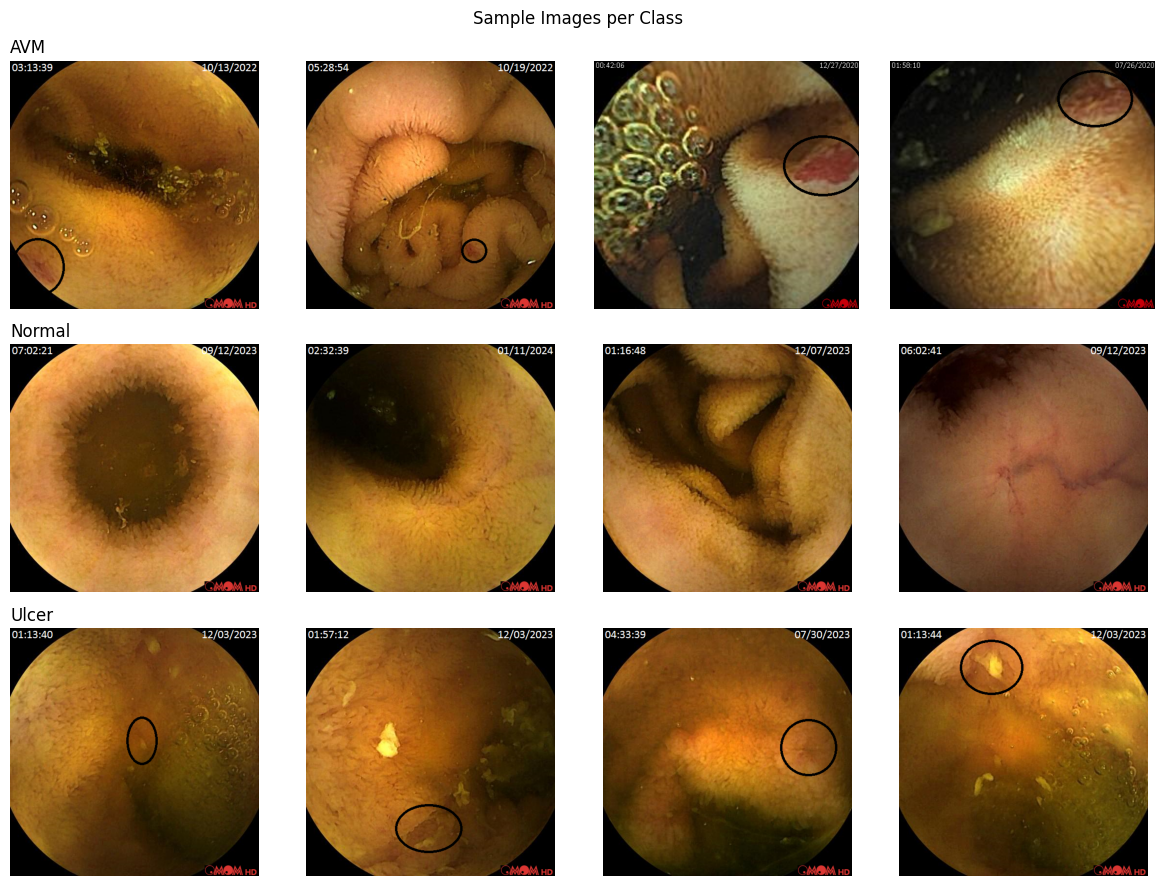

In [13]:

# Sample image grid per class
fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(12, 3*NUM_CLASSES))
for i, cls in enumerate(CLASS_NAMES):
    sample_paths = df[df.label == cls]["filepath"].sample(min(4, (df.label==cls).sum()), random_state=SEED).tolist()
    for j in range(4):
        ax = axes[i, j] if NUM_CLASSES > 1 else axes[j]
        if j < len(sample_paths):
            img = Image.open(sample_paths[j]).convert("RGB")
            ax.imshow(img)
        ax.axis("off")
        if j == 0:
            ax.set_ylabel(cls, fontsize=12)
    axes[i,0].set_title(cls, fontsize=12, loc="left")
plt.suptitle("Sample Images per Class")
plt.tight_layout()
plt.savefig("sample_grid.png", dpi=200)
plt.show()


## 3. Dataset & Transforms

In [14]:

IMG_SIZE = 224
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

label2idx = {c: i for i, c in enumerate(CLASS_NAMES)}
idx2label = {i: c for c, i in label2idx.items()}
df["label_idx"] = df["label"].map(label2idx)

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class CapsuleDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        img = self.transform(img)
        label = int(row["label_idx"])
        return img, label


## 4. Model — ConvNeXt V2 + Swin Transformer + Bidirectional Cross-Attention Fusion

- **ConvNeXt V2** stream: captures local texture / lesion-edge cues (CNN inductive bias).
- **Swin Transformer** stream: captures global / contextual cues (windowed self-attention).
- Final feature maps from both are projected to a shared embedding space, tokenized, and
  fused with **bidirectional cross-attention**: ConvNeXt tokens query Swin context and
  vice-versa, each refined with its own residual feed-forward block.
- Pooled fused tokens from both streams are concatenated → MLP classifier head (3 classes).

In [15]:

class CrossAttention(nn.Module):
    def __init__(self, dim, num_heads=8, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.q_proj = nn.Linear(dim, dim)
        self.k_proj = nn.Linear(dim, dim)
        self.v_proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(attn_drop)
        self.out_proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, q_tok, kv_tok):
        B, Nq, D = q_tok.shape
        Nk = kv_tok.shape[1]
        q = self.q_proj(q_tok).reshape(B, Nq, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(kv_tok).reshape(B, Nk, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(kv_tok).reshape(B, Nk, self.num_heads, self.head_dim).transpose(1, 2)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        out = (attn @ v).transpose(1, 2).reshape(B, Nq, D)
        return self.proj_drop(self.out_proj(out))


class BiCrossAttentionFusion(nn.Module):
    def __init__(self, dim, num_heads=8, mlp_ratio=4.0, drop=0.0):
        super().__init__()
        self.norm_q1 = nn.LayerNorm(dim); self.norm_kv1 = nn.LayerNorm(dim)
        self.cross_c2s = CrossAttention(dim, num_heads, proj_drop=drop)
        self.norm_q2 = nn.LayerNorm(dim); self.norm_kv2 = nn.LayerNorm(dim)
        self.cross_s2c = CrossAttention(dim, num_heads, proj_drop=drop)
        hidden = int(dim * mlp_ratio)
        self.norm_ff1 = nn.LayerNorm(dim)
        self.ff1 = nn.Sequential(nn.Linear(dim, hidden), nn.GELU(), nn.Dropout(drop),
                                  nn.Linear(hidden, dim), nn.Dropout(drop))
        self.norm_ff2 = nn.LayerNorm(dim)
        self.ff2 = nn.Sequential(nn.Linear(dim, hidden), nn.GELU(), nn.Dropout(drop),
                                  nn.Linear(hidden, dim), nn.Dropout(drop))

    def forward(self, conv_tok, swin_tok):
        conv_fused = conv_tok + self.cross_c2s(self.norm_q1(conv_tok), self.norm_kv1(swin_tok))
        conv_fused = conv_fused + self.ff1(self.norm_ff1(conv_fused))
        swin_fused = swin_tok + self.cross_s2c(self.norm_q2(swin_tok), self.norm_kv2(conv_tok))
        swin_fused = swin_fused + self.ff2(self.norm_ff2(swin_fused))
        return conv_fused, swin_fused


class ConvNeXtSwinFusionNet(nn.Module):
    def __init__(self, num_classes=3,
                 convnext_name="convnextv2_tiny.fcmae_ft_in22k_in1k",
                 swin_name="swin_tiny_patch4_window7_224.ms_in22k_ft_in1k",
                 fusion_dim=512, num_fusion_layers=2, num_heads=8,
                 drop_rate=0.1, pretrained=True, img_size=224):
        super().__init__()
        self.convnext = timm.create_model(convnext_name, pretrained=pretrained,
                                           features_only=True, out_indices=(-1,))
        self.swin = timm.create_model(swin_name, pretrained=pretrained,
                                       features_only=True, out_indices=(-1,), img_size=img_size)
        conv_out_ch = self.convnext.feature_info.channels()[-1]
        swin_out_ch = self.swin.feature_info.channels()[-1]

        self.conv_proj = nn.Conv2d(conv_out_ch, fusion_dim, kernel_size=1)
        self.swin_proj = nn.Linear(swin_out_ch, fusion_dim)

        self.conv_pos = nn.Parameter(torch.zeros(1, 49, fusion_dim))
        self.swin_pos = nn.Parameter(torch.zeros(1, 49, fusion_dim))
        nn.init.trunc_normal_(self.conv_pos, std=0.02)
        nn.init.trunc_normal_(self.swin_pos, std=0.02)

        self.fusion_blocks = nn.ModuleList([
            BiCrossAttentionFusion(fusion_dim, num_heads=num_heads, drop=drop_rate)
            for _ in range(num_fusion_layers)
        ])
        self.norm_conv_final = nn.LayerNorm(fusion_dim)
        self.norm_swin_final = nn.LayerNorm(fusion_dim)

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim), nn.GELU(), nn.Dropout(drop_rate),
            nn.Linear(fusion_dim, num_classes)
        )
        # store last feature maps for Grad-CAM hooks
        self._last_conv_map = None
        self._last_swin_map = None

    @staticmethod
    def _to_tokens(feat_map, channels_last):
        # channels_last=True  -> (B, H, W, C)   [timm Swin features_only output]
        # channels_last=False -> (B, C, H, W)   [timm ConvNeXt features_only output]
        if channels_last:
            B, H, W, C = feat_map.shape
            return feat_map.reshape(B, H * W, C)
        else:
            B, C, H, W = feat_map.shape
            return feat_map.flatten(2).transpose(1, 2)

    def _pos_embed(self, tokens, pos_param):
        N = tokens.shape[1]
        if pos_param.shape[1] != N:
            pos = pos_param.transpose(1, 2)
            pos = F.interpolate(pos, size=N, mode="linear", align_corners=False)
            pos = pos.transpose(1, 2)
        else:
            pos = pos_param
        return tokens + pos

    def forward(self, x):
        conv_feat = self.convnext(x)[-1]
        swin_feat = self.swin(x)[-1]
        self._last_conv_map = conv_feat
        self._last_swin_map = swin_feat

        conv_feat = self.conv_proj(conv_feat)
        conv_tokens = self._to_tokens(conv_feat, channels_last=False)
        swin_tokens = self._to_tokens(swin_feat, channels_last=True)
        swin_tokens = self.swin_proj(swin_tokens)

        conv_tokens = self._pos_embed(conv_tokens, self.conv_pos)
        swin_tokens = self._pos_embed(swin_tokens, self.swin_pos)

        for block in self.fusion_blocks:
            conv_tokens, swin_tokens = block(conv_tokens, swin_tokens)

        conv_tokens = self.norm_conv_final(conv_tokens)
        swin_tokens = self.norm_swin_final(swin_tokens)

        conv_pooled = conv_tokens.mean(dim=1)
        swin_pooled = swin_tokens.mean(dim=1)
        fused = torch.cat([conv_pooled, swin_pooled], dim=1)
        return self.classifier(fused)

print("Model class defined.")


Model class defined.


In [16]:

# Sanity check: forward pass with dummy batch
_test_model = ConvNeXtSwinFusionNet(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)
_dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    _out = _test_model(_dummy)
print("Output shape:", _out.shape)  # expect (2, 3)
del _test_model, _dummy, _out
gc.collect(); torch.cuda.empty_cache()


Output shape: torch.Size([2, 3])


## 5. Training / Evaluation Utilities (mixed precision, full metrics)

In [17]:

def run_epoch(model, loader, criterion, optimizer, scaler, device, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []

    torch.set_grad_enabled(train)
    for imgs, labels in loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        if train:
            optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=torch.cuda.is_available()):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        if train:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        total_loss += loss.item() * imgs.size(0)
        probs = F.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = probs.argmax(axis=1)
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.cpu().numpy().tolist())
        all_probs.extend(probs.tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, np.array(all_labels), np.array(all_preds), np.array(all_probs)


def compute_metrics(y_true, y_pred, y_probs, class_names):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    try:
        y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
        auc_macro = roc_auc_score(y_true_bin, y_probs, average="macro", multi_class="ovr")
    except Exception:
        auc_macro = float("nan")
    return {"accuracy": acc, "precision": precision, "recall": recall,
            "f1": f1, "auc_macro": auc_macro}


## 6. Stratified 10-Fold Cross-Validation Training

Trains a fresh fusion model per fold, tracks per-epoch curves, and evaluates on the held-out fold.
This is the gold-standard evaluation protocol expected for Q1 journal submissions on small
medical-imaging datasets.

In [ ]:

N_FOLDS = 10
EPOCHS_PER_FOLD = 12          # increase if you have more GPU time
BATCH_SIZE = 16
LR = 3e-5
WEIGHT_DECAY = 0.05
NUM_WORKERS = 2

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_results = []          # final metrics per fold
fold_histories = []        # per-epoch train/val loss & acc per fold
fold_predictions = []      # (y_true, y_pred, y_probs) per fold, concatenated later for overall ROC/CM
os.makedirs("fold_models", exist_ok=True)

X = df["filepath"].values
y = df["label_idx"].values

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n========== Fold {fold}/{N_FOLDS} ==========")
    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]

    train_ds = CapsuleDataset(train_df, train_tf)
    val_ds = CapsuleDataset(val_df, eval_tf)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)

    model = ConvNeXtSwinFusionNet(num_classes=NUM_CLASSES, pretrained=True, img_size=IMG_SIZE).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_PER_FOLD)
    scaler = GradScaler(enabled=torch.cuda.is_available())

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0
    best_state = None
    best_fold_preds = None

    for epoch in range(1, EPOCHS_PER_FOLD + 1):
        t0 = time.time()
        tr_loss, tr_acc, _, _, _ = run_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE, train=True)
        val_loss, val_acc, y_true, y_pred, y_probs = run_epoch(model, val_loader, criterion, optimizer, scaler, DEVICE, train=False)
        scheduler.step()

        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)

        print(f"  Epoch {epoch:02d}/{EPOCHS_PER_FOLD} | train_loss {tr_loss:.4f} acc {tr_acc:.4f} "
              f"| val_loss {val_loss:.4f} acc {val_acc:.4f} | {time.time()-t0:.1f}s")

        if val_acc >= best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            best_fold_preds = (y_true, y_pred, y_probs)

    torch.save(best_state, f"fold_models/fold_{fold}_best.pt")
    model.load_state_dict(best_state)

    y_true, y_pred, y_probs = best_fold_preds
    metrics = compute_metrics(y_true, y_pred, y_probs, CLASS_NAMES)
    metrics["fold"] = fold
    fold_results.append(metrics)
    fold_histories.append(history)
    fold_predictions.append(best_fold_preds)

    print(f"  Fold {fold} BEST -> acc {metrics['accuracy']:.4f} | f1 {metrics['f1']:.4f} | auc {metrics['auc_macro']:.4f}")

    del model, optimizer, scheduler, scaler
    gc.collect(); torch.cuda.empty_cache()

print("\n10-fold training complete.")



========== Fold 1/10 ==========


model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  Epoch 01/12 | train_loss 0.3967 acc 0.9416 | val_loss 0.3008 acc 1.0000 | 77.1s
  Epoch 02/12 | train_loss 0.3022 acc 0.9949 | val_loss 0.3049 acc 0.9909 | 56.2s
  Epoch 03/12 | train_loss 0.2952 acc 0.9986 | val_loss 0.2953 acc 1.0000 | 55.7s
  Epoch 04/12 | train_loss 0.2954 acc 0.9983 | val_loss 0.2926 acc 1.0000 | 56.0s
  Epoch 05/12 | train_loss 0.2917 acc 1.0000 | val_loss 0.2925 acc 1.0000 | 55.8s


## 7. Aggregated Results, Curves & Confusion Matrix (for the paper)

In [ ]:

results_df = pd.DataFrame(fold_results)
print(results_df)

summary = results_df[["accuracy", "precision", "recall", "f1", "auc_macro"]].agg(["mean", "std"])
print("\n=== 10-Fold Summary (mean ± std) ===")
for col in summary.columns:
    print(f"{col:>10s}: {summary[col]['mean']:.4f} ± {summary[col]['std']:.4f}")

results_df.to_csv("kfold_results.csv", index=False)
summary.to_csv("kfold_summary.csv")


In [ ]:

# Training/validation curves averaged across folds (mean +/- std band)
max_epochs = max(len(h["train_loss"]) for h in fold_histories)

def stack_metric(key):
    arr = np.full((len(fold_histories), max_epochs), np.nan)
    for i, h in enumerate(fold_histories):
        vals = h[key]
        arr[i, :len(vals)] = vals
    return arr

train_loss_arr = stack_metric("train_loss"); val_loss_arr = stack_metric("val_loss")
train_acc_arr = stack_metric("train_acc"); val_acc_arr = stack_metric("val_acc")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = np.arange(1, max_epochs+1)

for arr, label, ax in [(train_loss_arr, "Train Loss", axes[0]), (val_loss_arr, "Val Loss", axes[0])]:
    mean = np.nanmean(arr, axis=0); std = np.nanstd(arr, axis=0)
    ax.plot(epochs_range, mean, label=label)
    ax.fill_between(epochs_range, mean-std, mean+std, alpha=0.2)
axes[0].set_title("Loss Curves (mean ± std across 10 folds)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

for arr, label, ax in [(train_acc_arr, "Train Acc", axes[1]), (val_acc_arr, "Val Acc", axes[1])]:
    mean = np.nanmean(arr, axis=0); std = np.nanstd(arr, axis=0)
    ax.plot(epochs_range, mean, label=label)
    ax.fill_between(epochs_range, mean-std, mean+std, alpha=0.2)
axes[1].set_title("Accuracy Curves (mean ± std across 10 folds)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=300)
plt.show()


In [ ]:

# Pooled confusion matrix across all folds (out-of-fold predictions)
all_y_true = np.concatenate([p[0] for p in fold_predictions])
all_y_pred = np.concatenate([p[1] for p in fold_predictions])
all_y_probs = np.concatenate([p[2] for p in fold_predictions])

cm = confusion_matrix(all_y_true, all_y_pred)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Pooled Confusion Matrix (10-fold out-of-fold)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

print(classification_report(all_y_true, all_y_pred, target_names=CLASS_NAMES, digits=4))


In [ ]:

# ROC curves (one-vs-rest) pooled across all folds
y_true_bin = label_binarize(all_y_true, classes=list(range(NUM_CLASSES)))
fpr, tpr, roc_auc = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), all_y_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(7,6))
colors = sns.color_palette("husl", NUM_CLASSES)
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
              label=f"{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.3f})")
plt.plot(fpr["micro"], tpr["micro"], linestyle="--", color="black",
          label=f"micro-average (AUC = {roc_auc['micro']:.3f})")
plt.plot([0,1],[0,1], color="grey", lw=1, linestyle=":")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — ConvNeXtV2 + Swin Fusion (10-fold pooled)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=300)
plt.show()


## 8. Explainable AI (XAI) — Grad-CAM on ConvNeXt and Swin streams

We hook the last feature map of each backbone (captured during `forward()`) and apply
Grad-CAM to visualize which image regions drove the prediction for each stream, plus an
overlay comparing both — useful for clinical interpretability in the paper's discussion.

In [ ]:

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Reload best model from fold with highest val accuracy for XAI + deployment
best_fold_idx = int(results_df["accuracy"].idxmax())
best_fold_num = int(results_df.iloc[best_fold_idx]["fold"])
print(f"Using model from fold {best_fold_num} (best accuracy) for XAI & deployment.")

xai_model = ConvNeXtSwinFusionNet(num_classes=NUM_CLASSES, pretrained=False, img_size=IMG_SIZE).to(DEVICE)
xai_model.load_state_dict(torch.load(f"fold_models/fold_{best_fold_num}_best.pt", map_location=DEVICE))
xai_model.eval()


In [ ]:

def denormalize(img_tensor):
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(STD) + np.array(MEAN)
    return np.clip(img, 0, 1)

def gradcam_for_target_layer(model, target_layer, input_tensor, target_category):
    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(target_category)])[0]
    return grayscale_cam

# Target layers: last block of each backbone (the feature maps used for fusion)
conv_target_layer = xai_model.convnext.stages[-1].blocks[-1]   # ConvNeXtV2 last block
swin_target_layer = xai_model.swin.layers[-1].blocks[-1].norm2  # Swin last block norm

n_samples = min(6, len(val_ds) if 'val_ds' in dir() else 6)
sample_rows = df.sample(n_samples, random_state=SEED)

fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3*n_samples))
for i, (_, row) in enumerate(sample_rows.iterrows()):
    img = Image.open(row["filepath"]).convert("RGB")
    input_tensor = eval_tf(img).unsqueeze(0).to(DEVICE)
    rgb_img = denormalize(input_tensor[0])

    with torch.no_grad():
        out = xai_model(input_tensor)
        pred_class = out.argmax(dim=1).item()

    cam_conv = gradcam_for_target_layer(xai_model, conv_target_layer, input_tensor, pred_class)
    cam_swin = gradcam_for_target_layer(xai_model, swin_target_layer, input_tensor, pred_class)

    vis_conv = show_cam_on_image(rgb_img, cam_conv, use_rgb=True)
    vis_swin = show_cam_on_image(rgb_img, cam_swin, use_rgb=True)

    axes[i,0].imshow(rgb_img); axes[i,0].set_title(f"Input\nTrue: {row['label']} / Pred: {CLASS_NAMES[pred_class]}"); axes[i,0].axis("off")
    axes[i,1].imshow(vis_conv); axes[i,1].set_title("Grad-CAM: ConvNeXt V2"); axes[i,1].axis("off")
    axes[i,2].imshow(vis_swin); axes[i,2].set_title("Grad-CAM: Swin Transformer"); axes[i,2].axis("off")

plt.tight_layout()
plt.savefig("gradcam_xai.png", dpi=300)
plt.show()


## 9. Save Final Results Table & Best Model (for paper supplementary + deployment)

In [ ]:

final_report = {
    "model": "ConvNeXtV2-Tiny + Swin-Tiny + Bidirectional Cross-Attention Fusion",
    "dataset": "KAUHC Capsule Endoscopy",
    "classes": CLASS_NAMES,
    "n_folds": N_FOLDS,
    "epochs_per_fold": EPOCHS_PER_FOLD,
    "metrics_mean_std": {
        col: {"mean": float(summary[col]["mean"]), "std": float(summary[col]["std"])}
        for col in summary.columns
    },
    "best_fold": best_fold_num,
}
with open("final_report.json", "w") as f:
    json.dump(final_report, f, indent=2)

print(json.dumps(final_report, indent=2))

# Save the best overall model + class mapping for deployment
torch.save(xai_model.state_dict(), "best_model_for_deployment.pt")
with open("class_mapping.json", "w") as f:
    json.dump({"id2label": idx2label, "label2id": label2idx}, f, indent=2)

print("Saved: best_model_for_deployment.pt, class_mapping.json, final_report.json, kfold_results.csv")


## 10. Deploy to Hugging Face Hub

This pushes the model weights, a small inference wrapper, and a model card to a HF repo.
You need a Hugging Face **write** token — add it as a Kaggle Secret (`HF_TOKEN`) and it will
be picked up automatically, or paste it when prompted.

In [ ]:

from huggingface_hub import HfApi, create_repo, upload_file

# Try Kaggle Secrets first, fall back to manual input
HF_TOKEN = None
try:
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
except Exception:
    pass

if HF_TOKEN is None:
    HF_TOKEN = input("Paste your Hugging Face WRITE token: ").strip()

HF_USERNAME = input("Your Hugging Face username/org: ").strip()
REPO_NAME = "convnextv2-swin-capsule-endoscopy-kauhc"
REPO_ID = f"{HF_USERNAME}/{REPO_NAME}"

api = HfApi(token=HF_TOKEN)
create_repo(REPO_ID, token=HF_TOKEN, exist_ok=True, repo_type="model")
print(f"Repo ready: https://huggingface.co/{REPO_ID}")


In [ ]:

# Minimal inference wrapper script uploaded alongside weights so others can load it directly.
inference_code = '''
import torch, json
from PIL import Image
from torchvision import transforms
from huggingface_hub import hf_hub_download
import sys, os

sys.path.insert(0, os.path.dirname(__file__))
from modeling_fusion import ConvNeXtSwinFusionNet

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

def load_model(repo_id="REPO_ID_PLACEHOLDER", device="cpu"):
    weights_path = hf_hub_download(repo_id, "best_model_for_deployment.pt")
    mapping_path = hf_hub_download(repo_id, "class_mapping.json")
    with open(mapping_path) as f:
        mapping = json.load(f)
    id2label = {int(k): v for k, v in mapping["id2label"].items()}

    model = ConvNeXtSwinFusionNet(num_classes=len(id2label), pretrained=False)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.eval().to(device)
    return model, id2label

def predict(model, id2label, image_path, device="cpu"):
    img = Image.open(image_path).convert("RGB")
    x = tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(x), dim=1)[0]
    pred_idx = int(probs.argmax())
    return {"label": id2label[pred_idx], "confidence": float(probs[pred_idx]),
            "all_probs": {id2label[i]: float(p) for i, p in enumerate(probs)}}
'''.replace("REPO_ID_PLACEHOLDER", REPO_ID)

with open("inference.py", "w") as f:
    f.write(inference_code)

# Also export the model class definition standalone so inference.py can import it
import inspect
model_source = inspect.getsource(ConvNeXtSwinFusionNet.__mro__[0].__module__) if False else None
with open("modeling_fusion.py", "w") as f:
    f.write('''import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

''')
    # write out the class definitions we already have in this notebook's namespace
    import inspect as _inspect
    f.write(_inspect.getsource(CrossAttention) + "\n\n")
    f.write(_inspect.getsource(BiCrossAttentionFusion) + "\n\n")
    f.write(_inspect.getsource(ConvNeXtSwinFusionNet) + "\n")

print("Wrote inference.py and modeling_fusion.py")


In [ ]:

model_card = f'''---
license: apache-2.0
tags:
  - medical-imaging
  - capsule-endoscopy
  - convnext
  - swin-transformer
  - cross-attention
  - pytorch
  - image-classification
datasets:
  - nisarahmedrana/capsule-endoscopy-dataset-kauhc
metrics:
  - accuracy
  - f1
  - roc_auc
---

# ConvNeXt V2 + Swin Transformer + Cross-Attention Fusion — Capsule Endoscopy (KAUHC)

3-class classifier (**{', '.join(CLASS_NAMES)}**) for wireless capsule endoscopy frames, trained
on the KAUHC dataset with stratified 10-fold cross-validation.

## Architecture
- ConvNeXt V2 (tiny) backbone — local/texture features
- Swin Transformer (tiny) backbone — global/contextual features
- Bidirectional cross-attention fusion (2 layers) between both token streams
- MLP classification head

## 10-Fold Cross-Validation Results (mean ± std)

| Metric | Value |
|---|---|
| Accuracy | {summary["accuracy"]["mean"]:.4f} ± {summary["accuracy"]["std"]:.4f} |
| Precision (macro) | {summary["precision"]["mean"]:.4f} ± {summary["precision"]["std"]:.4f} |
| Recall (macro) | {summary["recall"]["mean"]:.4f} ± {summary["recall"]["std"]:.4f} |
| F1 (macro) | {summary["f1"]["mean"]:.4f} ± {summary["f1"]["std"]:.4f} |
| ROC-AUC (macro) | {summary["auc_macro"]["mean"]:.4f} ± {summary["auc_macro"]["std"]:.4f} |

## Usage
```python
from huggingface_hub import hf_hub_download
# see inference.py in this repo for load_model() / predict()
```

## Explainability
Grad-CAM visualizations for both the ConvNeXt and Swin streams are included in the
original training notebook to support clinical interpretability.
'''

with open("README.md", "w") as f:
    f.write(model_card)
print(model_card)


In [ ]:

files_to_upload = [
    "best_model_for_deployment.pt",
    "class_mapping.json",
    "final_report.json",
    "kfold_results.csv",
    "inference.py",
    "modeling_fusion.py",
    "README.md",
    "confusion_matrix.png",
    "roc_curves.png",
    "training_curves.png",
    "gradcam_xai.png",
]

for fp in files_to_upload:
    if os.path.exists(fp):
        api.upload_file(
            path_or_fileobj=fp,
            path_in_repo=fp,
            repo_id=REPO_ID,
            token=HF_TOKEN,
        )
        print(f"Uploaded {fp}")
    else:
        print(f"Skipped (not found): {fp}")

print(f"\nDeployed! View at: https://huggingface.co/{REPO_ID}")


## Summary

This notebook trained a **ConvNeXt V2 + Swin Transformer + Bidirectional Cross-Attention
Fusion** model for 3-class capsule endoscopy classification (`AVM`, `Normal`, `Ulcer`) using
**stratified 10-fold cross-validation**, generated all standard Q1-journal artifacts
(per-fold metrics table, mean±std summary, pooled confusion matrix, per-class ROC curves,
training/validation curves), produced **Grad-CAM** explainability visualizations for both
backbone streams, and deployed the best model + inference code + model card to the
**Hugging Face Hub**.

**Files produced:** `kfold_results.csv`, `kfold_summary.csv`, `final_report.json`,
`class_distribution.png`, `sample_grid.png`, `training_curves.png`, `confusion_matrix.png`,
`roc_curves.png`, `gradcam_xai.png`, `best_model_for_deployment.pt`, `class_mapping.json`,
`inference.py`, `modeling_fusion.py`, `README.md`.
